# 1. INTRODUÇÃO

Neste trabalho será realizada uma análise do conjunto de dados Wine Quality, que contém informações físico-químicas de vinhos tintos e brancos e suas respectivas avaliações de qualidade. O objetivo é explorar os dados, identificar relações entre as características dos vinhos e sua qualidade e utilizar algoritmos de Machine Learning para realizar classificações.

Serão utilizados os algoritmos K-Nearest Neighbors (KNN) e Random Forest. Ao final, os modelos serão avaliados e comparados por meio das métricas de acurácia, precisão, recall e F1-score, buscando identificar o modelo com melhor desempenho.

#2. IMPORTAÇÕES

## 2.1. Bibliotecas

Será utilizada a biblioteca Pandas para manipulação dos dados, NumPy para operações numéricas e Matplotlib para criação de gráficos e visualizações.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


##2.2. Carregamento dos dados

O conjunto de dados foi obtido a partir do Wine Quality Dataset e carregado utilizando a biblioteca Pandas.


In [4]:
red = pd.read_csv('/content/winequality-red.csv', sep=';')
white = pd.read_csv('/content/winequality-white.csv', sep=';')

red['type'] = 'red'
white['type'] = 'white'

dados = pd.concat([red, white], ignore_index=True)

print(dados.shape)

(6497, 13)


#3. CONHECENDO O DATASET

O dataset possui informações físico-químicas dos vinhos, como acidez, pH, sulfatos e teor alcoólico, além da variável quality, que representa sua qualidade.

In [5]:
dados.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
dados.shape

(6497, 13)

O dataset combinado possui 6497 registros e 13 colunas, sendo 12 relacionadas às características dos vinhos e uma coluna que identifica o tipo de vinho. As características incluem acidez, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos e teor alcoólico. A coluna quality representa a avaliação da qualidade do vinho.

In [7]:
dados.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [8]:
dados['quality'].value_counts().sort_index()

,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [10]:
dados.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


##3.1. VERIFICAÇÃO DOS DADOS

In [11]:
dados.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [12]:
dados.duplicated().sum()

np.int64(1177)

##3.2. CRIAÇÃO DA VARIÁVEL ALVO

In [13]:
dados_filtrado = dados[
    (dados['quality'] <= 4) | (dados['quality'] >= 7)
].copy()

dados_filtrado['tag'] = (
    dados_filtrado['quality'] >= 7
).astype(int)

print("Distribuição das qualidades:")
print(dados_filtrado['quality'].value_counts().sort_index())

print("\nDistribuição das classes:")
print(dados_filtrado['tag'].value_counts())

Distribuição das qualidades:
quality
3      30
4     216
7    1079
8     193
9       5
Name: count, dtype: int64

Distribuição das classes:
tag
1    1277
0     246
Name: count, dtype: int64


Para realizar a classificação, foram considerados apenas os vinhos com qualidade baixa (3 e 4) e qualidade alta (7, 8 e 9). Os vinhos com qualidade 5 e 6 foram retirados por representarem valores intermediários, tornando menos clara a separação entre as duas classes.

A variável tag foi criada para representar essas classes: 0 corresponde aos vinhos de baixa qualidade e 1 aos vinhos de boa qualidade.

In [14]:
print(dados_filtrado['quality'].value_counts().sort_index())
print()
print(dados_filtrado['tag'].value_counts())

quality
3      30
4     216
7    1079
8     193
9       5
Name: count, dtype: int64

tag
1    1277
0     246
Name: count, dtype: int64


#4. ANÁLISE EXPLORATÓRIA

##4.1. Vinhos com maior teor alcoólico tendem realmente a ser classificados como de boa qualidade?

In [15]:
media_alcool = dados_filtrado.groupby('tag')['alcohol'].mean()

print('Teor alcoólico médio:')
print('Baixa qualidade:', media_alcool[0])
print('Boa qualidade:', media_alcool[1])

Teor alcoólico médio:
Baixa qualidade: 10.184349593495934
Boa qualidade: 11.433359436178543


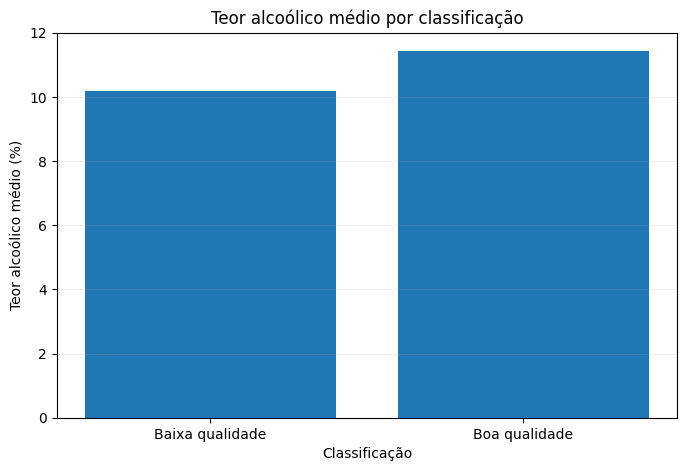

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    ['Baixa qualidade', 'Boa qualidade'],
    media_alcool.values
)

plt.xlabel('Classificação')
plt.ylabel('Teor alcoólico médio (%)')
plt.title('Teor alcoólico médio por classificação')
plt.grid(axis='y', alpha=0.2)

plt.show()

Os vinhos classificados como de boa qualidade apresentaram maior teor alcoólico médio do que os vinhos de baixa qualidade. Isso indica uma associação positiva entre o teor alcoólico e a classificação de qualidade no conjunto analisado.

In [17]:
diferenca = media_alcool[1] - media_alcool[0]

print('Diferença média de teor alcoólico:', diferenca)

Diferença média de teor alcoólico: 1.249009842682609


##4.2. A acidez volátil influencia negativamente a qualidade do vinho?

In [18]:
media_acidez = dados_filtrado.groupby('tag')['volatile acidity'].mean()

print('Acidez volátil média:')
print('Baixa qualidade:', media_acidez[0])
print('Boa qualidade:', media_acidez[1])

Acidez volátil média:
Baixa qualidade: 0.4651626016260163
Boa qualidade: 0.2891699295223179


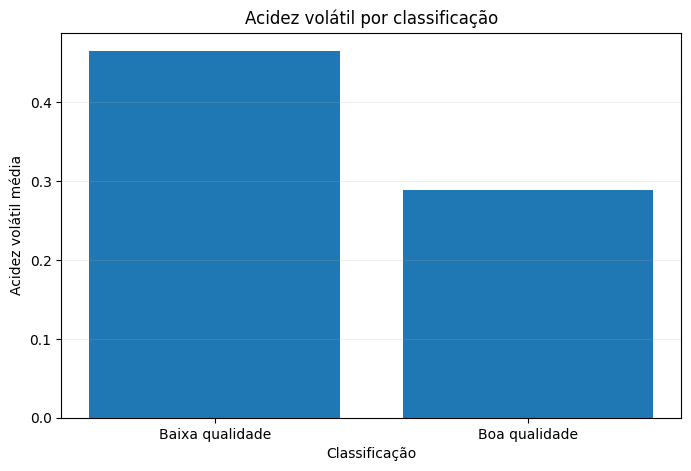

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    ['Baixa qualidade', 'Boa qualidade'],
    media_acidez.values
)

plt.xlabel('Classificação')
plt.ylabel('Acidez volátil média')
plt.title('Acidez volátil por classificação')
plt.grid(axis='y', alpha=0.2)

plt.show()

Os vinhos de baixa qualidade apresentaram maior acidez volátil média do que os vinhos de boa qualidade. Portanto, os dados indicam uma associação negativa entre a acidez volátil e a classificação de qualidade.

In [20]:
diferenca = media_acidez[0] - media_acidez[1]

print('Diferença média de acidez volátil:', diferenca)

Diferença média de acidez volátil: 0.1759926721036984


##4.3. Quais características apresentam maior diferença entre vinhos de boa e baixa qualidade?

In [21]:
medias = dados_filtrado.groupby('tag').mean(numeric_only=True)

diferencas = (
    medias.loc[1] - medias.loc[0]
).abs()

diferencas = diferencas.drop('quality')

diferencas = diferencas.sort_values(
    ascending=False
)

print(diferencas.round(4))

free sulfur dioxide     8.1528
total sulfur dioxide    4.1899
alcohol                 1.2490
residual sugar          0.5537
fixed acidity           0.2720
volatile acidity        0.1760
citric acid             0.0613
sulphates               0.0358
chlorides               0.0176
pH                      0.0071
density                 0.0019
dtype: float64


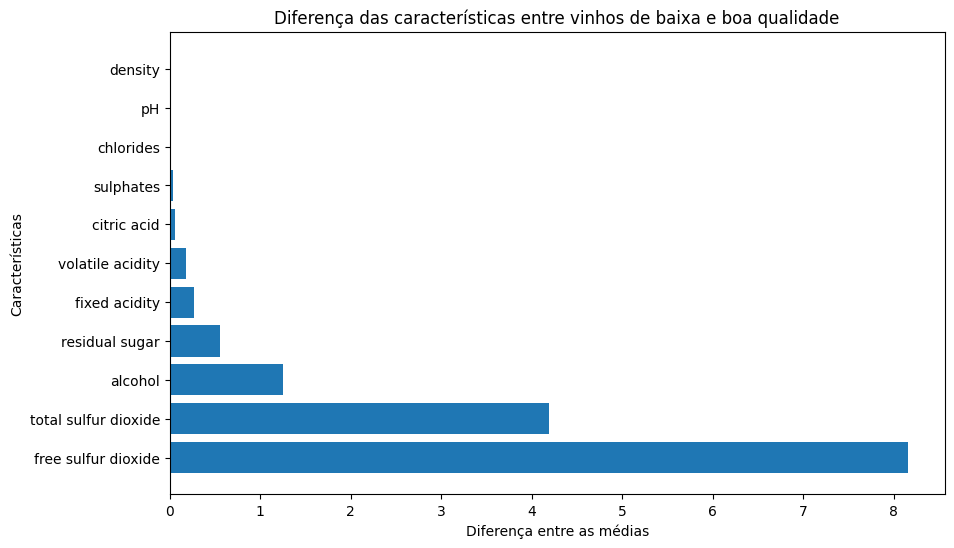

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(diferencas.index, diferencas.values)

plt.xlabel('Diferença entre as médias')
plt.ylabel('Características')
plt.title('Diferença das características entre vinhos de baixa e boa qualidade')

plt.show()

###4.3.1. CONCLUSÃO

A característica que apresentou maior diferença entre os grupos foi o dióxido de enxofre total, seguido pelo teor alcoólico e pela acidez volátil. Vinhos de boa qualidade apresentaram menor dióxido de enxofre total e menor acidez volátil, além de maior teor alcoólico. Já características como pH, densidade e açúcar residual apresentaram pouca diferença entre os grupos.

##4.4 O tipo de vinho influência na qualidade?

In [23]:
proporcao = dados_filtrado.groupby('type')['tag'].mean() * 100

print('Percentual de vinhos de boa qualidade:')
print('Tintos:', round(proporcao.iloc[0], 2), '%')
print('Brancos:', round(proporcao.iloc[1], 2), '%')

Percentual de vinhos de boa qualidade:
Tintos: 77.5 %
Brancos: 85.28 %


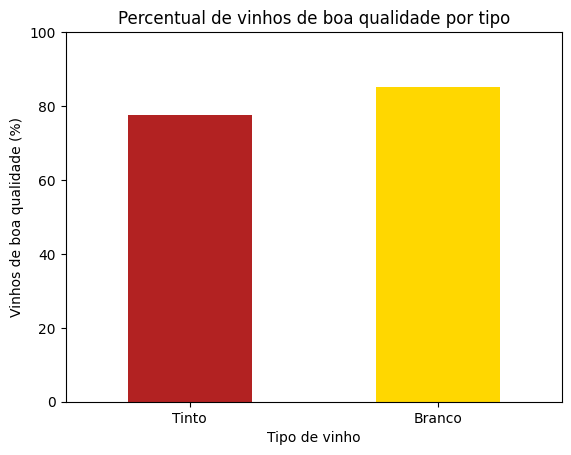

In [24]:
import matplotlib.pyplot as plt

proporcao.plot(kind='bar', color=['firebrick', 'gold'])

plt.title('Percentual de vinhos de boa qualidade por tipo')
plt.xlabel('Tipo de vinho')
plt.ylabel('Vinhos de boa qualidade (%)')
plt.xticks([0, 1], ['Tinto', 'Branco'], rotation=0)
plt.ylim(0, 100)
plt.show()

Os vinhos brancos apresentaram maior percentual de boa qualidade (85,28%) em comparação aos vinhos tintos (77,50%). Isso indica que, na amostra analisada, os vinhos brancos tiveram maior proporção de classificações de boa qualidade.

#5. Preparação para Machine Learning

Para aplicar os modelos de Machine Learning, a variável quality foi retirada das entradas, pois ela representa a informação que originou a classificação. A variável tag foi utilizada como variável alvo.

Os dados foram divididos em 80% para treinamento e 20% para teste. Essa divisão permite utilizar a maior parte dos dados para treinamento e reservar uma parcela para avaliar o desempenho dos modelos em dados que não foram utilizados durante o treinamento.

In [25]:
dados_filtrado['type'] = dados_filtrado['type'].map({
    'red': 0,
    'white': 1
})

In [26]:
from sklearn.model_selection import train_test_split

X = dados_filtrado.drop(columns=['quality', 'tag'])
y = dados_filtrado['tag']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Dados de treinamento:', X_train.shape)
print('Dados de teste:', X_test.shape)

Dados de treinamento: (1218, 12)
Dados de teste: (305, 12)


#6. K-Nearest Neighbors (KNN)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred_knn))
print("Precisão:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-score:", f1_score(y_test, y_pred_knn))

Acurácia: 0.9147540983606557
Precisão: 0.9227941176470589
Recall: 0.98046875
F1-score: 0.9507575757575758


O modelo KNN apresentou 91,48% de acurácia, 92,28% de precisão, 98,05% de recall e 95,08% de F1-score. O resultado indica um bom desempenho na classificação dos vinhos.

#7. Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

Acurácia: 0.9442622950819672
Precisão: 0.9509433962264151
Recall: 0.984375
F1-score: 0.9673704414587332


O modelo Random Forest apresentou 94,43% de acurácia, 95,09% de precisão, 98,44% de recall e 96,74% de F1-score. Entre as métricas avaliadas, o modelo apresentou os melhores resultados em comparação com o KNN.

#8. Comparação dos Modelos

In [29]:
resultados = pd.DataFrame({
    'Modelo': ['KNN', 'Random Forest'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precisão': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,KNN,0.914754,0.922794,0.980469,0.950758
1,Random Forest,0.944262,0.950943,0.984375,0.967370


#9. Conclusão

A análise exploratória mostrou diferenças entre os vinhos de baixa e boa qualidade, principalmente em relação ao dióxido de enxofre total, teor alcoólico e acidez volátil.

Na etapa de Machine Learning, os dois modelos apresentaram desempenho superior a 85% de acurácia. O KNN alcançou 91,48%, enquanto o Random Forest obteve 94,43% de acurácia, além de apresentar os melhores resultados de precisão, recall e F1-score.

Dessa forma, o Random Forest foi escolhido como o melhor modelo para a classificação dos vinhos. O resultado demonstra que as características físico-químicas utilizadas possuem informações relevantes para diferenciar os grupos de qualidade analisados.

#10. Salvando o melhor modelo

In [30]:
import joblib

joblib.dump(rf, 'modelo.joblib')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
